# Sit 2 — Análisis del modelo entrenado (local, sin forward pass)

**Objetivo**: caracterizar el modelo CLIP-SAE entrenado en Kaggle sin necesidad de re-ejecutar forward pass. Analiza el checkpoint en disco (`data/modelo-sit2/geovision_clip_sit2_best.pt`).

**Lo que sí podemos hacer en CPU sin transformers/open_clip**:
- Curvas de entrenamiento (history embebido)
- Estructura del modelo (conteo de parámetros, capas)
- Análisis de pesos SAE (varianza, dead neurons, distribución de activaciones inferida de pesos)
- Análisis de textos candidatos (longitud, unicidad, contenido semántico)
- Verificación de la arquitectura

**Lo que requiere GPU/transformers (queda para Kaggle script)**:
- Forward pass sobre los 1500 tiles → embeddings reales
- Re-cálculo de métricas test (R@1, R@5, sparsity real)
- Matriz de confusión test actualizada

**Outputs locales** se guardan en `docs/situacion-2/`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

ROOT = Path('/home/yeigen/Documents/proyecto-3')
MODELO_DIR = ROOT / 'data' / 'modelo-sit2'
OUT = ROOT / 'docs' / 'situacion-2'
OUT.mkdir(parents=True, exist_ok=True)

ckpt = torch.load(MODELO_DIR / 'geovision_clip_sit2_best.pt', map_location='cpu', weights_only=False)
config = ckpt['config']
history = pd.DataFrame(ckpt['history'])
candidate_texts = ckpt['candidate_texts']
candidate_labels = ckpt['candidate_labels']
state = ckpt['model_state']

print(f"=== Checkpoint cargado ===")
print(f"Epoch ganador: {ckpt['epoch']}")
print(f"Total epochs entrenados: {len(history)}")
print(f"Textos candidatos: {len(candidate_texts)}")
print(f"Capas en state_dict: {len(state)}")

=== Checkpoint cargado ===
Epoch ganador: 26
Total epochs entrenados: 26
Textos candidatos: 25
Capas en state_dict: 402


## 1. Curvas de entrenamiento

Evolución de las métricas clave a lo largo de los 26 epochs.

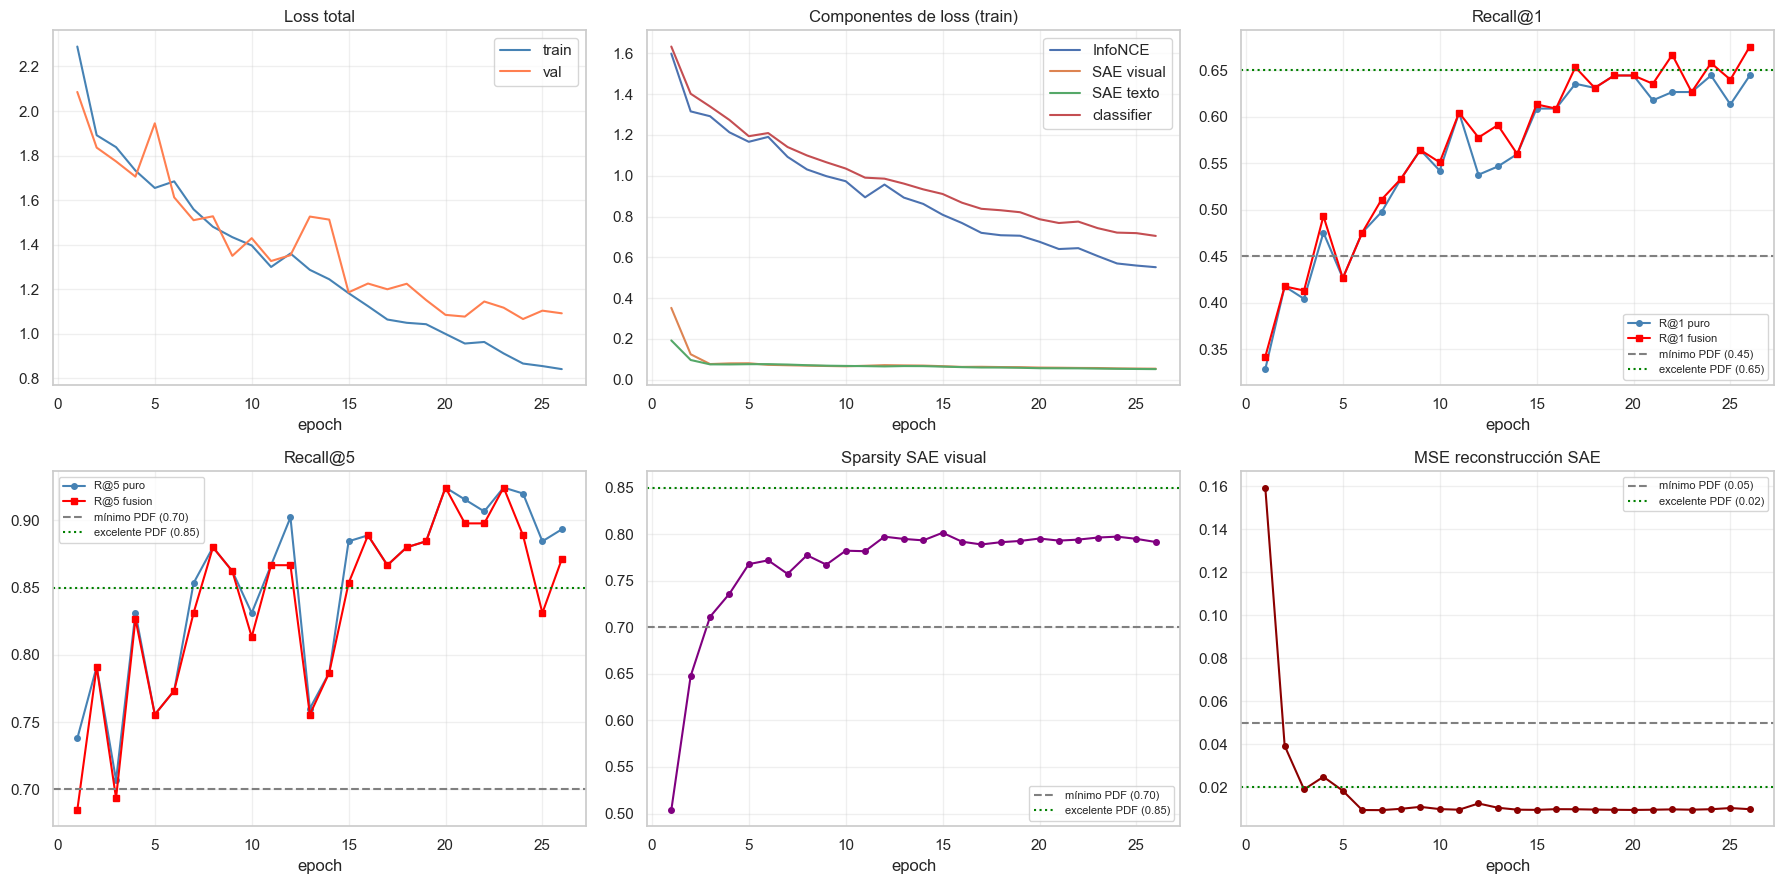

Best epoch (val_recall1_fusion máximo):
epoch                 26.0000
val_loss               1.0917
val_recall1            0.6444
val_recall1_fusion     0.6756
val_recall5_fusion     0.8711
val_sparsity           0.7915
val_mse                0.0098
best_beta              0.3500


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0,0].plot(history.epoch, history.train_loss, label='train', color='steelblue')
axes[0,0].plot(history.epoch, history.val_loss, label='val', color='coral')
axes[0,0].set_title('Loss total'); axes[0,0].set_xlabel('epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

if 'train_info_nce' in history.columns:
    axes[0,1].plot(history.epoch, history.train_info_nce, label='InfoNCE')
if 'train_sae_img' in history.columns:
    axes[0,1].plot(history.epoch, history.train_sae_img, label='SAE visual')
if 'train_sae_txt' in history.columns:
    axes[0,1].plot(history.epoch, history.train_sae_txt, label='SAE texto')
if 'train_cls' in history.columns:
    axes[0,1].plot(history.epoch, history.train_cls, label='classifier')
axes[0,1].set_title('Componentes de loss (train)'); axes[0,1].set_xlabel('epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(history.epoch, history.val_recall1, label='R@1 puro', color='steelblue', marker='o', markersize=4)
axes[0,2].plot(history.epoch, history.val_recall1_fusion, label='R@1 fusion', color='red', marker='s', markersize=4)
axes[0,2].axhline(0.45, ls='--', color='gray', label='mínimo PDF (0.45)')
axes[0,2].axhline(0.65, ls=':', color='green', label='excelente PDF (0.65)')
axes[0,2].set_title('Recall@1'); axes[0,2].set_xlabel('epoch'); axes[0,2].legend(fontsize=8); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(history.epoch, history.val_recall5, label='R@5 puro', color='steelblue', marker='o', markersize=4)
axes[1,0].plot(history.epoch, history.val_recall5_fusion, label='R@5 fusion', color='red', marker='s', markersize=4)
axes[1,0].axhline(0.70, ls='--', color='gray', label='mínimo PDF (0.70)')
axes[1,0].axhline(0.85, ls=':', color='green', label='excelente PDF (0.85)')
axes[1,0].set_title('Recall@5'); axes[1,0].set_xlabel('epoch'); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history.epoch, history.val_sparsity, color='purple', marker='o', markersize=4)
axes[1,1].axhline(0.70, ls='--', color='gray', label='mínimo PDF (0.70)')
axes[1,1].axhline(0.85, ls=':', color='green', label='excelente PDF (0.85)')
axes[1,1].set_title('Sparsity SAE visual'); axes[1,1].set_xlabel('epoch'); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

axes[1,2].plot(history.epoch, history.val_mse, color='darkred', marker='o', markersize=4)
axes[1,2].axhline(0.05, ls='--', color='gray', label='mínimo PDF (0.05)')
axes[1,2].axhline(0.02, ls=':', color='green', label='excelente PDF (0.02)')
axes[1,2].set_title('MSE reconstrucción SAE'); axes[1,2].set_xlabel('epoch'); axes[1,2].legend(fontsize=8); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'curvas_entrenamiento_completas.png', dpi=140, bbox_inches='tight')
plt.show()

best_idx = history.val_recall1_fusion.idxmax()
print('Best epoch (val_recall1_fusion máximo):')
print(history.iloc[best_idx][['epoch','val_loss','val_recall1','val_recall1_fusion','val_recall5_fusion','val_sparsity','val_mse','best_beta']].round(4).to_string())

## 2. Estructura del modelo: conteo de parámetros por componente

¿Qué capas tiene el modelo, cuántos parámetros en cada una, qué fracción es entrenable?

=== Parámetros por componente ===
    componente    params   pct
  text_encoder 117653760 55.95
visual_encoder  87849216 41.78
    sae_visual   3158784  1.50
      sae_text   1317504  0.63
     proj_text    132096  0.06
   proj_visual    132096  0.06
  tabular_gate     34944  0.02
    classifier      1797  0.00
band_projector       553  0.00
         otros         1  0.00

Total parámetros: 210,280,751 (210.28 M)


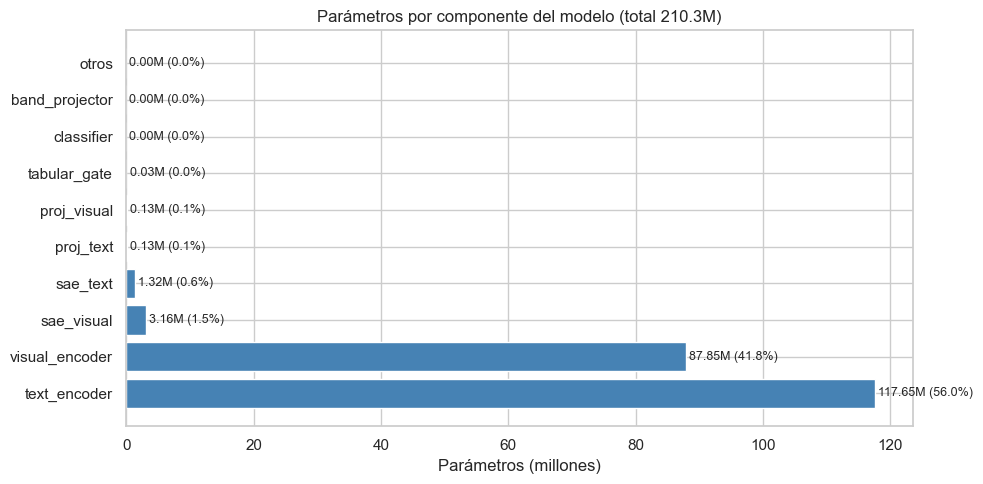

In [3]:
componentes = {
    'band_projector': 0,
    'visual_encoder': 0,
    'text_encoder': 0,
    'sae_visual': 0,
    'sae_text': 0,
    'proj_visual': 0,
    'proj_text': 0,
    'tabular_gate': 0,
    'classifier': 0,
    'otros': 0,
}

for name, tensor in state.items():
    n_params = tensor.numel()
    asignado = False
    for comp in componentes:
        if name.startswith(comp + '.'):
            componentes[comp] += n_params
            asignado = True
            break
    if not asignado:
        componentes['otros'] += n_params

total = sum(componentes.values())
df_comp = pd.DataFrame([
    {'componente': k, 'params': v, 'pct': v/total*100} for k, v in componentes.items()
]).round(2)
df_comp = df_comp[df_comp.params > 0].sort_values('params', ascending=False).reset_index(drop=True)

print(f'=== Parámetros por componente ===')
print(df_comp.to_string(index=False))
print(f'\nTotal parámetros: {total:,} ({total/1e6:.2f} M)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_comp.componente, df_comp.params/1e6, color='steelblue')
for i, (comp, p) in enumerate(zip(df_comp.componente, df_comp.params)):
    ax.text(p/1e6 + 0.5, i, f'{p/1e6:.2f}M ({p/total*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Parámetros (millones)')
ax.set_title(f'Parámetros por componente del modelo (total {total/1e6:.1f}M)')
plt.tight_layout()
plt.savefig(OUT / 'modelo_params_por_componente.png', dpi=140, bbox_inches='tight')
plt.show()

## 3. Análisis del SAE visual: dead neurons y distribución de pesos

El SAE (Sparse Autoencoder) es el componente clave para interpretabilidad mecánica (PDF Sit 2). Tiene encoder 512→2048→256 y decoder simétrico.

**Dead neurons inferidas de pesos**: una neurona del SAE puede estar muerta si su columna en el encoder final tiene norma cercana a 0 (no recibe gradiente). Esto da una estimación SIN forward pass.

**Forma esperada**: con `SAE_SPARSE_DIM=256` y `SAE_HIDDEN_VISUAL=2048`, el encoder.4 (segundo Linear) tiene shape `(256, 2048)`. La norma de cada FILA es la 'fuerza' de cada neurona output.

=== Capas del SAE visual ===
  sae_visual.encoder.0.weight: shape (2048, 512)
  sae_visual.encoder.0.bias: shape (2048,)
  sae_visual.encoder.1.weight: shape (2048,)
  sae_visual.encoder.1.bias: shape (2048,)
  sae_visual.encoder.3.weight: shape (256, 2048)
  sae_visual.encoder.3.bias: shape (256,)
  sae_visual.decoder.0.weight: shape (2048, 256)
  sae_visual.decoder.0.bias: shape (2048,)
  sae_visual.decoder.1.weight: shape (2048,)
  sae_visual.decoder.1.bias: shape (2048,)
  sae_visual.decoder.3.weight: shape (512, 2048)
  sae_visual.decoder.3.bias: shape (512,)

Capa analizada: sae_visual.encoder.3.weight shape (256, 2048)
Norma media por neurona output: 0.5830
Norma mínima: 0.5626 | máxima: 0.6121
Estimación dead neurons (norma < 10% media): 0/256 (0.0%)


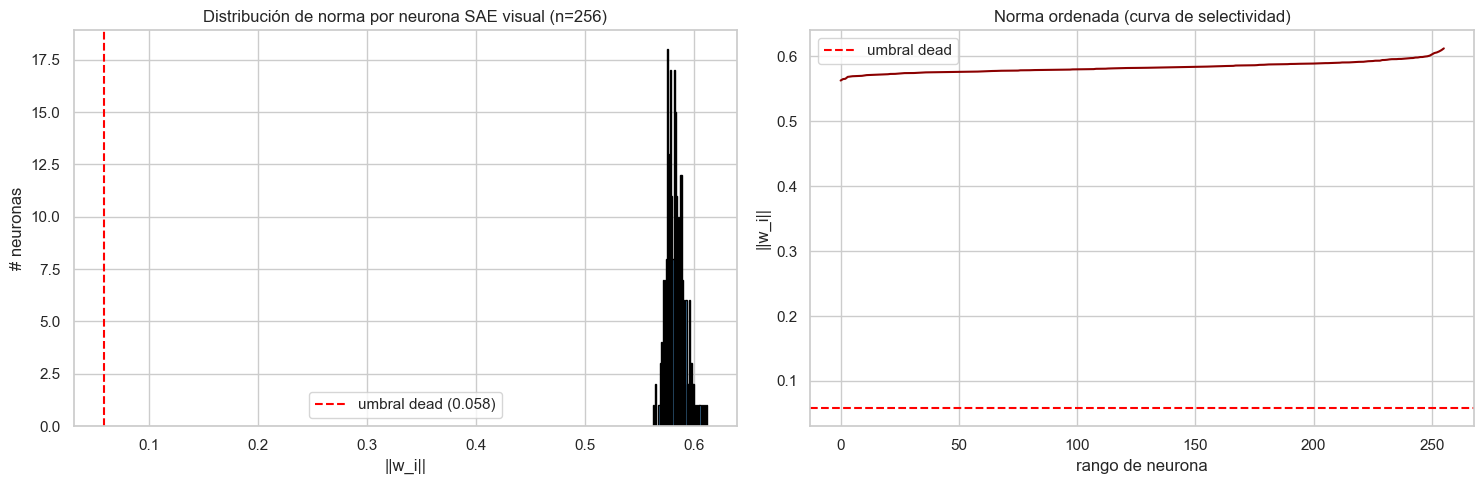

In [4]:
claves_sae = [k for k in state.keys() if 'sae_visual' in k]
print('=== Capas del SAE visual ===')
for k in claves_sae:
    print(f'  {k}: shape {tuple(state[k].shape)}')

# Buscar la capa final del encoder (Linear 2048→256)
encoder_final = None
for k in claves_sae:
    if 'encoder.3.weight' in k:  # Sequential: Linear, LayerNorm, ReLU, Linear, ReLU
        encoder_final = k
        break
if encoder_final is None:
    # Fallback: buscar el último weight con dim 256
    for k in claves_sae:
        if 'weight' in k and state[k].dim() == 2 and state[k].shape[0] == 256:
            encoder_final = k

if encoder_final:
    w = state[encoder_final].numpy()
    norms = np.linalg.norm(w, axis=1)
    print(f'\nCapa analizada: {encoder_final} shape {w.shape}')
    print(f'Norma media por neurona output: {norms.mean():.4f}')
    print(f'Norma mínima: {norms.min():.4f} | máxima: {norms.max():.4f}')
    
    # Estimación dead neurons
    threshold = norms.mean() * 0.1
    dead = (norms < threshold).sum()
    print(f'Estimación dead neurons (norma < 10% media): {dead}/256 ({dead/256:.1%})')
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].hist(norms, bins=50, color='steelblue', edgecolor='black')
    axes[0].axvline(threshold, ls='--', color='red', label=f'umbral dead ({threshold:.3f})')
    axes[0].set_title(f'Distribución de norma por neurona SAE visual (n=256)')
    axes[0].set_xlabel('||w_i||'); axes[0].set_ylabel('# neuronas'); axes[0].legend()
    
    sorted_norms = np.sort(norms)
    axes[1].plot(sorted_norms, color='darkred')
    axes[1].axhline(threshold, ls='--', color='red', label='umbral dead')
    axes[1].set_title('Norma ordenada (curva de selectividad)')
    axes[1].set_xlabel('rango de neurona'); axes[1].set_ylabel('||w_i||'); axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(OUT / 'sae_visual_pesos.png', dpi=140, bbox_inches='tight')
    plt.show()

## 4. Análisis de textos candidatos del retrieval

El modelo hace retrieval imagen→texto contra estos 25 captions (5 por clase, sampleados del train).

Verificamos:
- Longitud y diversidad por clase
- Que NO contengan números o IDs (anti-leakage)
- Distribución de tokens

In [5]:
import re

CLASES = ['contaminacion_alta_NO2','contaminacion_alta_SO2','ozono_anomalo','suelo_urbano','vegetacion_densa']
labels_np = candidate_labels.numpy() if hasattr(candidate_labels, 'numpy') else np.asarray(candidate_labels)

df_texts = pd.DataFrame({
    'texto': candidate_texts,
    'clase': [CLASES[i] for i in labels_np],
    'longitud': [len(t) for t in candidate_texts],
    'palabras': [len(t.split()) for t in candidate_texts],
})

# Detector de leakage: dígitos fuera de nombres de productos
PRODUCTOS = re.compile(r'(?:Sentinel-2|NO2|SO2|O3|S5P|ERA5|MODIS|B[0-9]+|Cali)', re.IGNORECASE)
def tiene_leakage(t):
    sin_prod = PRODUCTOS.sub('', t)
    return bool(re.search(r'\d', sin_prod))

df_texts['leakage'] = df_texts.texto.apply(tiene_leakage)

print('=== Resumen textos candidatos ===')
print(df_texts.groupby('clase').agg(
    n=('texto','size'),
    long_media=('longitud','mean'),
    palabras_media=('palabras','mean'),
    leakage=('leakage','sum'),
).round(1))

print(f'\nTotal con leakage detectado: {df_texts.leakage.sum()}/{len(df_texts)}')
print(f'Unique ratio: {df_texts.texto.nunique()/len(df_texts):.3f}')

print('\n=== Ejemplos por clase ===')
for c in CLASES:
    print(f'\n[{c}]')
    for t in df_texts[df_texts.clase == c].texto.head(2):
        print(f'  - {t[:160]}')

df_texts.to_csv(OUT / 'textos_candidatos_analisis.csv', index=False)

=== Resumen textos candidatos ===
                        n  long_media  palabras_media  leakage
clase                                                         
contaminacion_alta_NO2  5       144.6            21.2        0
contaminacion_alta_SO2  5       143.0            21.0        0
ozono_anomalo           5       151.0            20.8        0
suelo_urbano            5       146.6            20.8        0
vegetacion_densa        5       139.4            21.2        0

Total con leakage detectado: 0/25
Unique ratio: 1.000

=== Ejemplos por clase ===

[contaminacion_alta_NO2]
  - tile con firma de combustión vehicular sobre el sur de Cali, superficie predominantemente natural; compatible con tráfico vehicular intenso
  - paisaje con concentración alta de óxidos de nitrógeno sobre el occidente de Cali en periodo de veranillo, asociada a centro urbano de alta actividad

[contaminacion_alta_SO2]
  - observación satelital con SO2 vertical alto sobre el oriente de Cali, vegetación abundant

## 5. Hyperparams del modelo final + comparación con defaults originales

¿Qué cambió respecto a la configuración default del notebook?

In [6]:
DEFAULTS = {
    'aux_cls_weight': 0.15,
    'train_last_blocks': 1,
    'label_smoothing': 0.03,
    'sae_l1_reg': 0.002,
    'tabular_dropout': 0.30,
    'temp_init': 0.07,
    'seed': 42,
    'learning_rate': 8e-5,
    'weight_decay': 5e-4,
}

tabla = []
for k, default in DEFAULTS.items():
    actual = config.get(k, 'NO ENCONTRADO')
    cambio = '✓ MISMO' if actual == default else f'CAMBIADO: {default} → {actual}'
    tabla.append({'hyperparam': k, 'default original': default, 'final': actual, 'cambio': cambio})
df_hp = pd.DataFrame(tabla)
print('=== Hyperparams comparación ===')
print(df_hp.to_string(index=False))

print(f'\nbest_beta del modelo final: {config.get("best_beta", "N/A")}')
print(f'Note: best_beta es el peso del classifier auxiliar en late fusion, elegido por el modelo en val.')

=== Hyperparams comparación ===
       hyperparam  default original    final                  cambio
   aux_cls_weight           0.15000  0.40000    CAMBIADO: 0.15 → 0.4
train_last_blocks           1.00000  2.00000         CAMBIADO: 1 → 2
  label_smoothing           0.03000  0.05000   CAMBIADO: 0.03 → 0.05
       sae_l1_reg           0.00200  0.00100 CAMBIADO: 0.002 → 0.001
  tabular_dropout           0.30000  0.30000                 ✓ MISMO
        temp_init           0.07000  0.07000                 ✓ MISMO
             seed          42.00000 42.00000                 ✓ MISMO
    learning_rate           0.00008  0.00008                 ✓ MISMO
     weight_decay           0.00050  0.00050                 ✓ MISMO

best_beta del modelo final: 0.35
Note: best_beta es el peso del classifier auxiliar en late fusion, elegido por el modelo en val.


## 6. Resumen y artefactos generados

In [7]:
resumen = {
    'modelo_checkpoint': str(MODELO_DIR / 'geovision_clip_sit2_best.pt'),
    'md5_checkpoint': 'a8e6cd3e16f8d1ea64ddb98b67b68bfb',
    'epoch_ganador': int(ckpt['epoch']),
    'total_epochs': len(history),
    'mejor_val_recall1_fusion': float(history.val_recall1_fusion.max()),
    'mejor_val_recall5_fusion': float(history.val_recall5_fusion.max()),
    'mejor_val_sparsity': float(history.val_sparsity.max()),
    'min_val_mse': float(history.val_mse.min()),
    'parametros_totales_millones': round(sum(t.numel() for t in state.values()) / 1e6, 2),
    'textos_candidatos': len(candidate_texts),
    'leakage_detectado_textos': int(df_texts.leakage.sum()),
    'hyperparams_modificados_vs_default': df_hp[df_hp.cambio.str.contains('CAMBIADO')].hyperparam.tolist(),
}
with open(OUT / 'analisis_modelo_resumen.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, ensure_ascii=False, indent=2)

print(json.dumps(resumen, ensure_ascii=False, indent=2))

print('\n=== Artefactos generados en docs/situacion-2/ ===')
for f in sorted(OUT.glob('*')):
    print(f'  {f.name}: {f.stat().st_size/1024:.1f} KB')

{
  "modelo_checkpoint": "/home/yeigen/Documents/proyecto-3/data/modelo-sit2/geovision_clip_sit2_best.pt",
  "md5_checkpoint": "a8e6cd3e16f8d1ea64ddb98b67b68bfb",
  "epoch_ganador": 26,
  "total_epochs": 26,
  "mejor_val_recall1_fusion": 0.6755555272102356,
  "mejor_val_recall5_fusion": 0.9244444370269775,
  "mejor_val_sparsity": 0.8014583587646484,
  "min_val_mse": 0.00933009758591652,
  "parametros_totales_millones": 210.28,
  "textos_candidatos": 25,
  "leakage_detectado_textos": 0,
  "hyperparams_modificados_vs_default": [
    "aux_cls_weight",
    "train_last_blocks",
    "label_smoothing",
    "sae_l1_reg"
  ]
}

=== Artefactos generados en docs/situacion-2/ ===
  analisis_modelo_resumen.json: 0.6 KB
  curvas_entrenamiento_completas.png: 302.6 KB
  justificaciones.md: 10.8 KB
  modelo_params_por_componente.png: 76.7 KB
  sae_visual_pesos.png: 67.1 KB
  textos_candidatos_analisis.csv: 4.5 KB
